# Visualising a Manufacturing Quality Perceptron

With two measured inputs, we can see the inspected parts and the perceptron's linear decision boundary on one plot. We will follow the boundary during training, inspect unseen predictions, and finish with a concrete limitation of a single threshold.

> The measurements are realistic synthetic teaching data, not a production quality-control dataset.

## 1. Plot the inspected parts

The feature order is `[dimension_error_mm, surface_defects]`. Blue squares are accepted parts (`1`); coral circles are rejected parts (`0`).

In [7]:
import numpy as np
import matplotlib.pyplot as plt

X_train = np.array([
    [0.10, 0.0], [0.15, 1.0], [0.20, 0.0], [0.25, 1.0],
    [0.30, 0.0], [0.05, 1.0], [0.55, 0.0], [0.45, 2.0],
    [0.20, 3.0], [0.70, 1.0], [0.35, 2.0], [0.60, 2.0],
])
y_train = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])
part_ids = ["P01", "P02", "P03", "P04", "P05", "P06",
            "P07", "P08", "P09", "P10", "P11", "P12"]

X_test = np.array([[0.12, 0.0], [0.28, 1.0], [0.50, 1.0], [0.10, 3.0]])
y_test = np.array([1, 1, 0, 0])
test_ids = ["T01", "T02", "T03", "T04"]

print(f"Training parts: {len(X_train)}")
print(f"Unseen test parts: {len(X_test)}")

Training parts: 12
Unseen test parts: 4


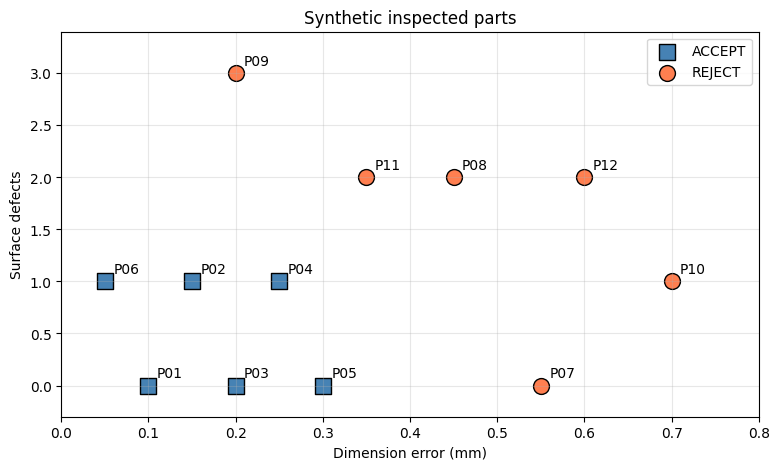

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
accept_mask = y_train == 1
reject_mask = y_train == 0
ax.scatter(X_train[accept_mask, 0], X_train[accept_mask, 1], color="steelblue", marker="s", s=130, edgecolors="black", label="ACCEPT")
ax.scatter(X_train[reject_mask, 0], X_train[reject_mask, 1], color="coral", marker="o", s=130, edgecolors="black", label="REJECT")
for part_id, features in zip(part_ids, X_train):
    ax.annotate(part_id, features, xytext=(6, 6), textcoords="offset points")
ax.set_xlabel("Dimension error (mm)")
ax.set_ylabel("Surface defects")
ax.set_title("Synthetic inspected parts")
ax.set_xlim(0.0, 0.8)
ax.set_ylim(-0.3, 3.4)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 2. Train and record the boundary

After initialization and after every epoch, store a copy of the weights and bias. The step activation function converts each score into a class: scores at or above zero map to `1`, and scores below zero map to `0`. The stored snapshots let us replay how the linear boundary moves.

In [9]:
np.random.seed(42)
weights = np.random.uniform(-1, 1, size=2)
bias = float(np.random.uniform(-1, 1))
learning_rate = 0.1
max_epochs = 100

weight_history = [(weights.copy(), bias)]
error_history = []

for epoch in range(max_epochs):
    scores = X_train @ weights + bias
    # Step activation function: scores >= 0 map to 1; scores < 0 map to 0.
    predictions = (scores >= 0).astype(int)
    errors = y_train - predictions
    error_count = np.count_nonzero(errors)

    error_history.append(int(error_count))
    print(f"Epoch {epoch + 1:3d} | Errors: {error_count}")
    if error_count == 0:
        print(f"Training complete after {epoch + 1} epoch(s).")
        break

    weights += learning_rate * (X_train.T @ errors)
    bias += learning_rate * errors.sum()
else:
    raise RuntimeError("The perceptron did not converge within 100 epochs.")

Epoch   1 | Errors: 6
Epoch   2 | Errors: 6
Epoch   3 | Errors: 6
Epoch   4 | Errors: 6
Epoch   5 | Errors: 4
Epoch   6 | Errors: 3
Epoch   7 | Errors: 3
Epoch   8 | Errors: 2
Epoch   9 | Errors: 3
Epoch  10 | Errors: 1
Epoch  11 | Errors: 0
Training complete after 11 epoch(s).


## 3. Draw the learned decision regions

The boundary contains every point whose score is zero. One side produces `ACCEPT`; the other produces `REJECT`.

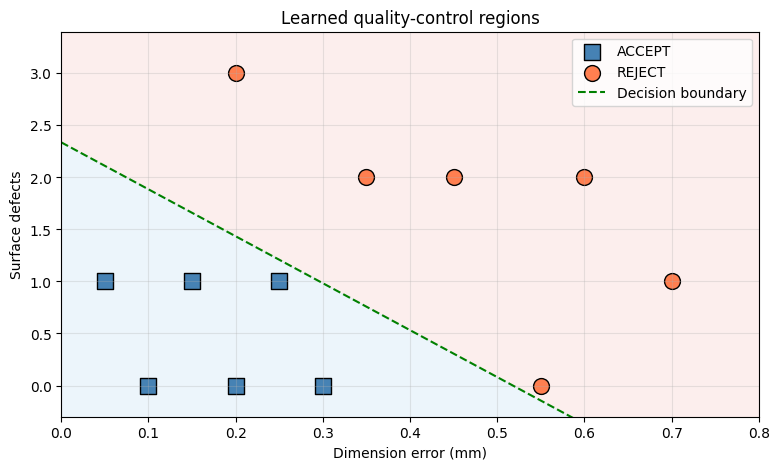

In [10]:
def plot_decision_boundary(weights, bias, axis, label="Decision boundary"):
    """Plot w_error*x + w_defects*y + bias = 0."""
    if abs(weights[1]) < 1e-12:
        axis.axvline(-bias / weights[0], linestyle="--", color="green", label=label)
        return

    x_values = np.linspace(0.0, 0.8, 200)
    y_values = -(weights[0] * x_values + bias) / weights[1]
    axis.plot(x_values, y_values, linestyle="--", color="green", label=label)


def shade_regions(weights, bias, axis):
    x_values = np.linspace(0.0, 0.8, 240)
    y_values = np.linspace(-0.3, 3.4, 240)
    xx, yy = np.meshgrid(x_values, y_values)
    scores = weights[0] * xx + weights[1] * yy + bias
    axis.contourf(xx, yy, scores, levels=[-100, 0, 100], colors=["#FADBD8", "#D6EAF8"], alpha=0.45)


fig, ax = plt.subplots(figsize=(9, 5))
shade_regions(weights, bias, ax)
ax.scatter(X_train[accept_mask, 0], X_train[accept_mask, 1], color="steelblue", marker="s", s=130, edgecolors="black", label="ACCEPT")
ax.scatter(X_train[reject_mask, 0], X_train[reject_mask, 1], color="coral", marker="o", s=130, edgecolors="black", label="REJECT")
plot_decision_boundary(weights, bias, ax)
ax.set_xlabel("Dimension error (mm)")
ax.set_ylabel("Surface defects")
ax.set_title("Learned quality-control regions")
ax.set_xlim(0.0, 0.8)
ax.set_ylim(-0.3, 3.4)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 4. Watch the boundary move

The initial line is random. Each mistake moves it until all training observations are on the intended side.

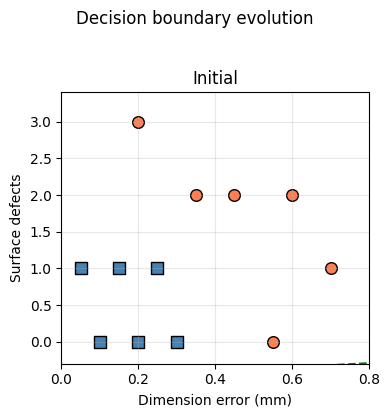

In [11]:
snapshot_count = min(len(weight_history), 6)
snapshot_indices = np.linspace(0, len(weight_history) - 1, snapshot_count, dtype=int)
fig, axes = plt.subplots(1, snapshot_count, figsize=(4 * snapshot_count, 4), sharey=True)
axes = np.atleast_1d(axes)

for axis, snapshot_index in zip(axes, snapshot_indices):
    snapshot_weights, snapshot_bias = weight_history[snapshot_index]
    axis.scatter(X_train[accept_mask, 0], X_train[accept_mask, 1], color="steelblue", marker="s", s=70, edgecolors="black")
    axis.scatter(X_train[reject_mask, 0], X_train[reject_mask, 1], color="coral", marker="o", s=70, edgecolors="black")
    plot_decision_boundary(snapshot_weights, snapshot_bias, axis)
    title = "Initial" if snapshot_index == 0 else f"Epoch {snapshot_index}"
    axis.set_title(title)
    axis.set_xlabel("Dimension error (mm)")
    axis.set_xlim(0.0, 0.8)
    axis.set_ylim(-0.3, 3.4)
    axis.grid(alpha=0.3)
axes[0].set_ylabel("Surface defects")
plt.suptitle("Decision boundary evolution", y=1.03)
plt.tight_layout()
plt.show()

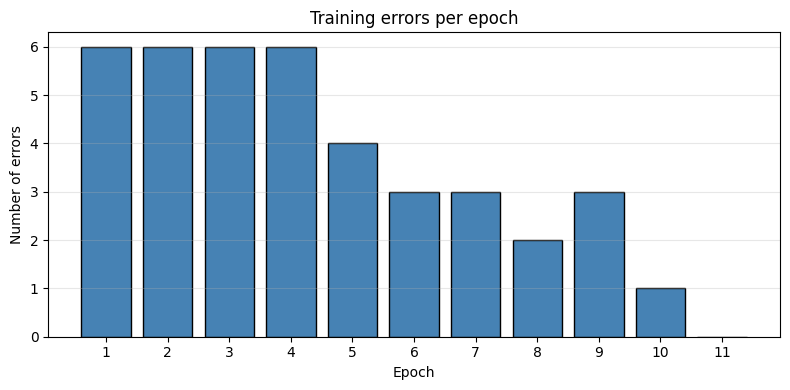

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs = np.arange(1, len(error_history) + 1)
ax.bar(epochs, error_history, color="steelblue", edgecolor="black")
ax.set_xlabel("Epoch")
ax.set_ylabel("Number of errors")
ax.set_title("Training errors per epoch")
ax.set_xticks(epochs)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Place unseen parts on the learned map

The test parts were not used to move the boundary. Their locations make each prediction visible.

T01: ACCEPT
T02: ACCEPT
T03: REJECT
T04: REJECT


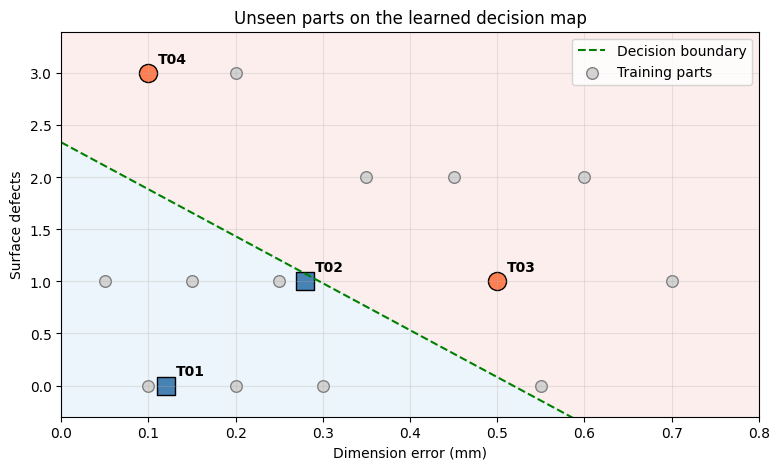

In [13]:
test_scores = X_test @ weights + bias
# Step activation function: scores >= 0 map to 1; scores < 0 map to 0.
test_predictions = (test_scores >= 0).astype(int)
assert np.array_equal(test_predictions, y_test)

fig, ax = plt.subplots(figsize=(9, 5))
shade_regions(weights, bias, ax)
plot_decision_boundary(weights, bias, ax)
ax.scatter(X_train[:, 0], X_train[:, 1], color="lightgray", s=70, edgecolors="gray", label="Training parts")
for part_id, features, prediction in zip(test_ids, X_test, test_predictions):
    color = "steelblue" if prediction == 1 else "coral"
    marker = "s" if prediction == 1 else "o"
    ax.scatter(features[0], features[1], color=color, marker=marker, s=170, edgecolors="black")
    ax.annotate(part_id, features, xytext=(7, 7), textcoords="offset points", fontweight="bold")
    label = "ACCEPT" if prediction == 1 else "REJECT"
    print(f"{part_id}: {label}")
ax.set_xlabel("Dimension error (mm)")
ax.set_ylabel("Surface defects")
ax.set_title("Unseen parts on the learned decision map")
ax.set_xlim(0.0, 0.8)
ax.set_ylim(-0.3, 3.4)
ax.legend()
ax.grid(alpha=0.3)
plt.show()